In [24]:
import networkx as nx
import numpy as np
from pipeline.calculate_metrics import half_edge, edge, moran, moran_dist, dissimilarity
import matplotlib.pyplot as plt
import pipeline.calculate_metrics

In [25]:
def make_double_star(n): #graph w/ 2n+ 1 edges, 2n + 2 nodes
    G = nx.Graph()
    G.add_edge(0, 1)
    for i in range(n):
        G.add_edges_from([(0, i + 2) for i in range(n)])
        G.add_edges_from([(1, i + n + 2) for i in range(n)])
    return G

In [26]:
def build_x(a, n):
    x = np.zeros(2 * n + 2)
    x[0] = 2
    x[1] = 0
    for i in range(n):
        x[i + 2] = 1 + a
        x[i + n + 2] = 1 - a
    return x

In [31]:
x = build_x(.5, 50)
y = 2 - x
t = x + y

In [34]:
len(t)

102

In [35]:
def populate(graph, x, y, t):
    for node, i in enumerate(graph.nodes):
        graph.nodes[node]['x'] = x[node]
        graph.nodes[node]['y'] = y[node]
        graph.nodes[node]['t'] = t[node]
    return graph

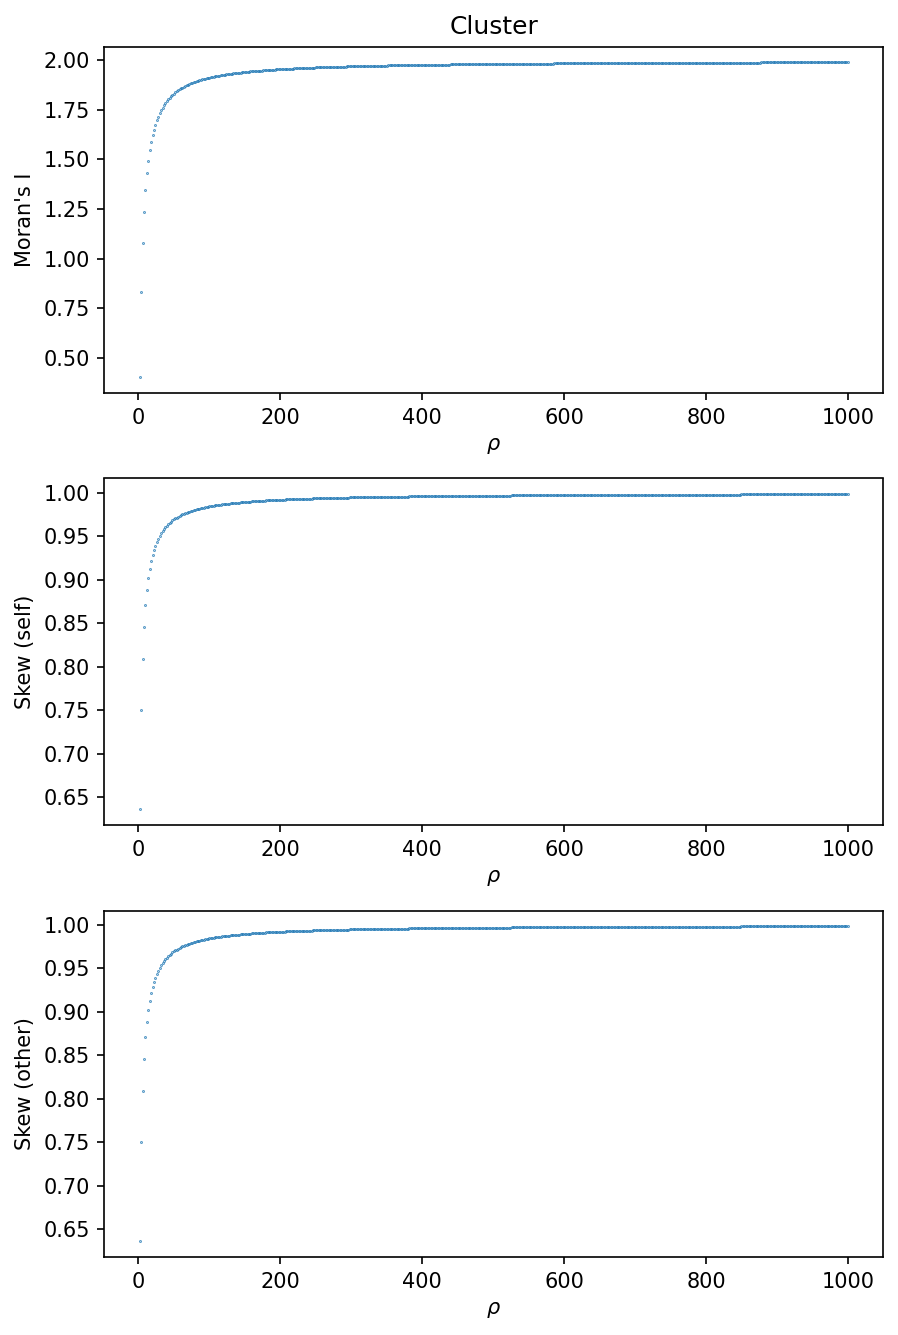

In [39]:
morans = []
skew_selfs = []
skew_others = []
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))

ns = np.linspace(2, 1000, 500)

for n in ns:
    g = make_double_star(int(n))
    x = build_x(.5,  int(n))
    y = 2 - x
    t = x + y  
    g = populate(g, x, y, t)
    skew_others.append(pipeline.calculate_metrics.skew(g, "y", "x"))
    skew_selfs.append(pipeline.calculate_metrics.skew(g, "x", "y"))
    morans.append(pipeline.calculate_metrics.moran(g, "x", "t")["moran_A"])



ax1.scatter(ns, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")


# Self skew
ax2.scatter(ns, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")


# Other skew
ax3.scatter(ns, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")


plt.tight_layout()
plt.show()



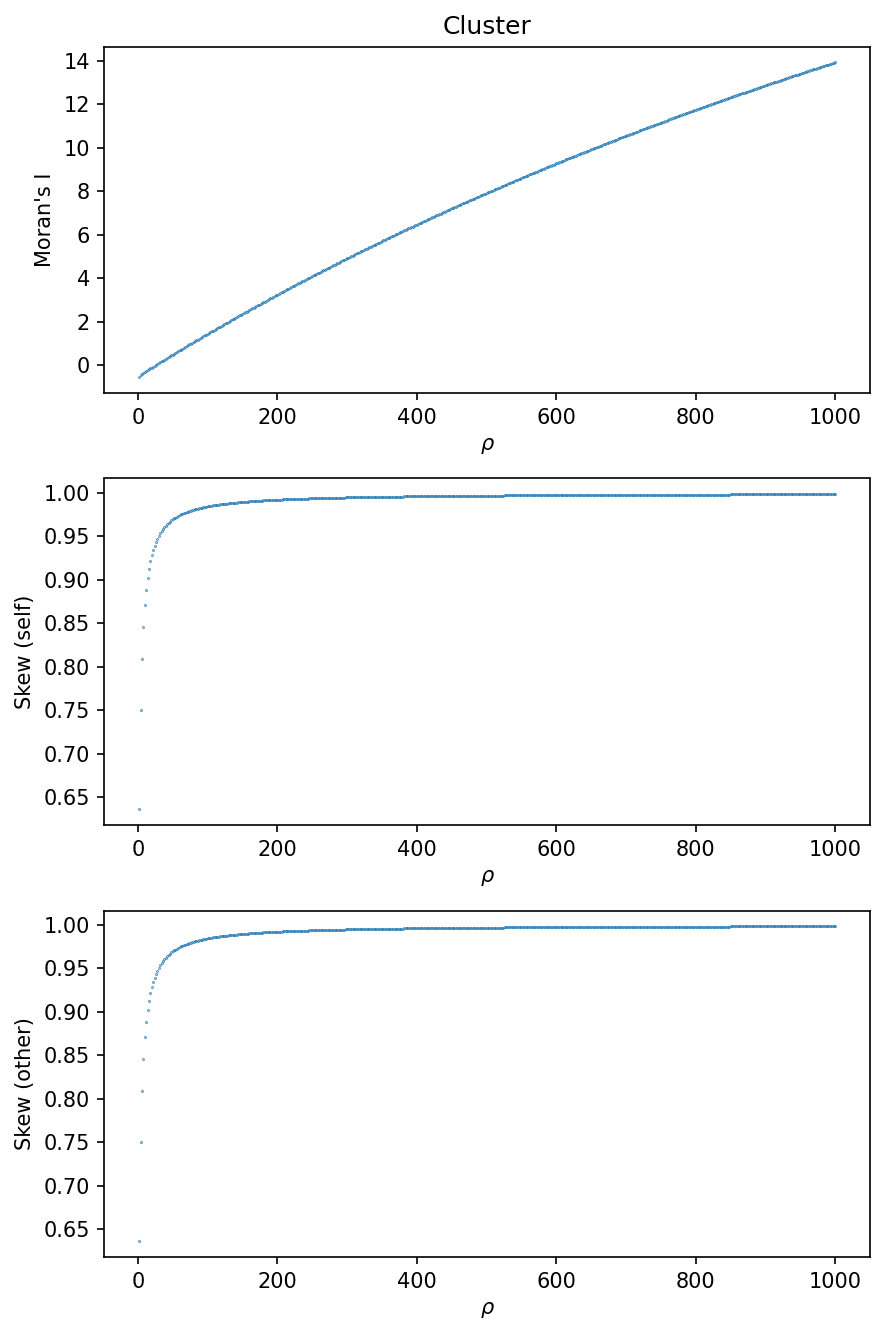

In [40]:
morans = []
skew_selfs = []
skew_others = []
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))

ns = np.linspace(2, 1000, 500)

for n in ns:
    g = make_double_star(int(n))
    x = build_x(1/50,  int(n))
    y = 2 - x
    t = x + y  
    g = populate(g, x, y, t)
    skew_others.append(pipeline.calculate_metrics.skew(g, "y", "x"))
    skew_selfs.append(pipeline.calculate_metrics.skew(g, "x", "y"))
    morans.append(pipeline.calculate_metrics.moran(g, "x", "t")["moran_A"])



ax1.scatter(ns, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")


# Self skew
ax2.scatter(ns, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")


# Other skew
ax3.scatter(ns, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")


plt.tight_layout()
plt.show()


/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:362: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


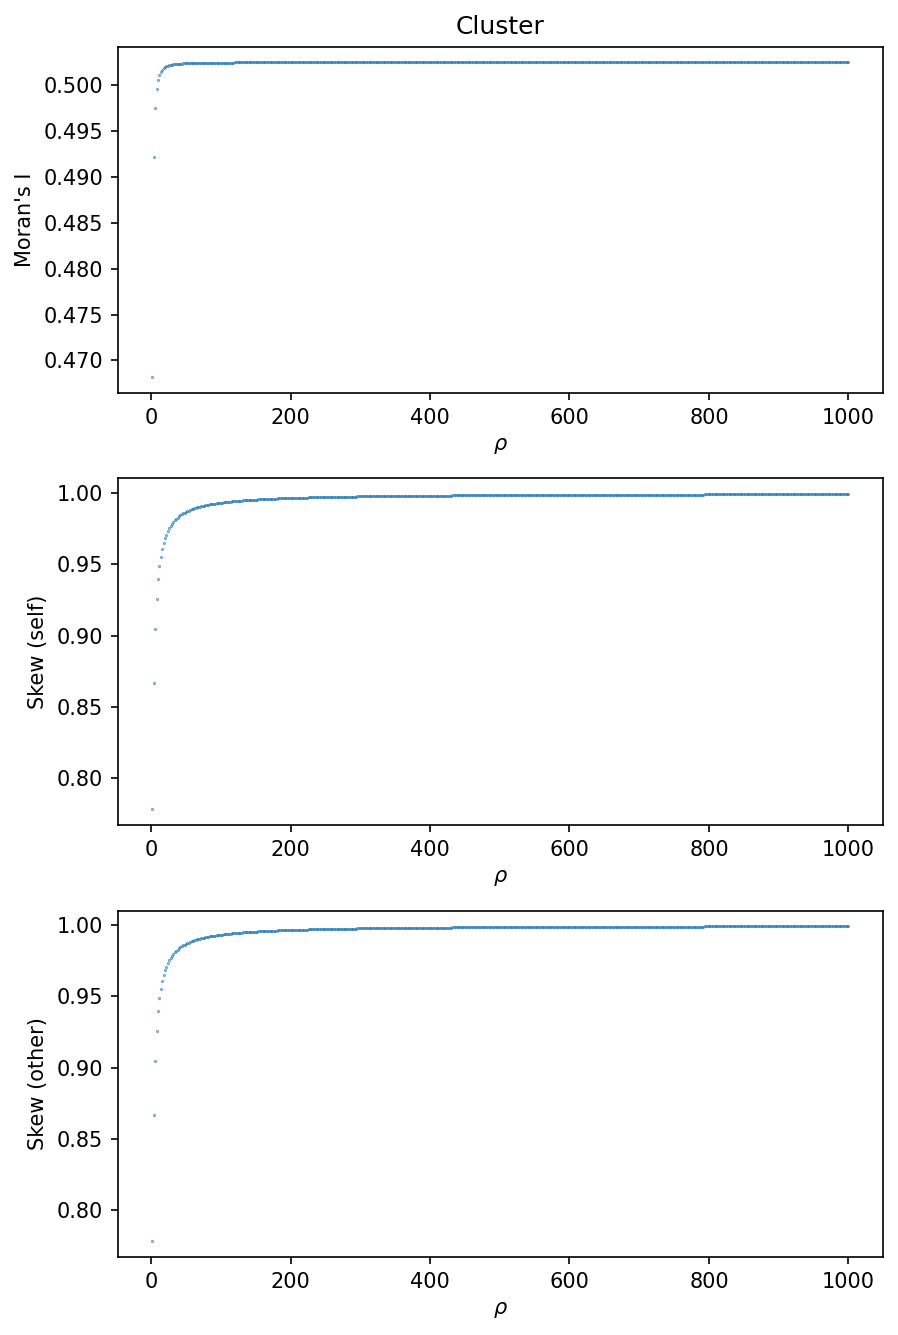

In [41]:
morans = []
skew_selfs = []
skew_others = []
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, dpi=150, figsize=(6, 9))

ns = np.linspace(2, 1000, 500)

for n in ns:
    g = make_double_star(int(n))
    x = build_x(1.99,  int(n))
    y = 2 - x
    t = x + y  
    g = populate(g, x, y, t)
    skew_others.append(pipeline.calculate_metrics.skew(g, "y", "x"))
    skew_selfs.append(pipeline.calculate_metrics.skew(g, "x", "y"))
    morans.append(pipeline.calculate_metrics.moran(g, "x", "t")["moran_A"])



ax1.scatter(ns, morans, s=0.1)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel("Moran's I")
ax1.set_title("Cluster")


# Self skew
ax2.scatter(ns, skew_selfs, s=0.1)
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel("Skew (self)")


# Other skew
ax3.scatter(ns, skew_others, s=0.1)
ax3.set_xlabel(r'$\rho$')
ax3.set_ylabel("Skew (other)")


plt.tight_layout()
plt.show()